# Launch Failure Deep Dive

This notebook extends the earlier launch-failure notebooks by following the same priority
order used in the previous improvement analysis:

1. add precision-recall analysis and validation-based threshold tuning
2. build split-safe historical reliability features
3. audit and refine the weather block
4. run targeted error analysis by rocket family, operator, site, and year

The target remains `is_failure_or_partial`, where:

- `1` means a failed or partially failed launch
- `0` means a successful launch

The notebook keeps the same high-level comparison structure as the earlier work:

- a **launch-only** model
- a **launch + weather** model, with a later ablation step that tests whether a narrower
  weather block performs better than the full weather field

The key difference is that both models now use:

- a more curated feature-engineering stage
- time-safe historical reliability features
- site-relative weather anomaly features that compare current conditions to what is normal
  at that launch site
- model selection based on validation precision-recall behavior rather than only default-threshold accuracy

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import PredefinedSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder

ROOT = Path.cwd()
if not (ROOT / "launch_modeling_base_with_weather.csv").exists() and (
    ROOT.parent / "launch_modeling_base_with_weather.csv"
).exists():
    ROOT = ROOT.parent
DATA_PATH = ROOT / "launch_modeling_base_with_weather.csv"

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)

RANDOM_STATE = 42
TARGET_COL = "is_failure_or_partial"

## Load the Modeling Table

This notebook starts from the same cleaned launch-level table used in the earlier modeling
notebooks so the incremental gains can be attributed to better analysis and feature design,
not to a different source dataset.

In [2]:
df = pd.read_csv(DATA_PATH)
df["launch_dt"] = pd.to_datetime(df["launch_time_utc"], errors="coerce", utc=True)
df = df.sort_values(["launch_dt", "Launch Id"]).reset_index(drop=True)

print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
print("\nSplit counts:")
print(df["data_split"].value_counts().sort_index())
print("\nFailure share by split:")
print(df.groupby("data_split")[TARGET_COL].mean().round(4))

df.head()

Dataset shape: 6,168 rows x 89 columns

Split counts:
data_split
test           926
train         4317
validation     925
Name: count, dtype: int64

Failure share by split:
data_split
test          0.0594
train         0.0996
validation    0.0616
Name: is_failure_or_partial, dtype: float64


,Launch Id,launch_time_utc,launch_date,launch_year,launch_month,launch_month_name,launch_quarter,launch_dayofweek,launch_hour_utc,launch_decade,Launch Status,is_success,is_failure_or_partial,Launch Suborbital,is_suborbital,Rocket Name,Rocket Organisation,company_country,company_ownership,Rocket Price,Rocket Price CPI Adjusted,Rocket Payload to LEO,USD/kg to LEO,USD/kg to LEO CPI Adjusted,Location,Country,Country_Code,Operator,Launch Site,Comb Launch Site,facility_group,Lat,Lon,Launch Site Lat,Launch Site Lon,Comb Launch Site Lat,Comb Launch Site Lon,facility_lat,facility_lon,facility_coordinate_source,payload_count,mission_mass,mission_rows,config_status,config_price_musd_text_parsed,config_liftoff_thrust,config_payload_leo,config_payload_gto,config_stages,config_strap_ons,config_rocket_height,config_fairing_diameter,config_fairing_height,rocket_family,family_success_rate_pct,location_joined,mission_joined,config_joined,company_joined,launch_time_lstd,weather_obs_time_lstd,weather_matched,weather_time_diff_minutes,weather_file_name,weather_station_id,DATE,REPORT_TYPE,HourlyDryBulbTemperature,HourlyDewPointTemperature,HourlySeaLevelPressure,HourlyWindSpeed,HourlyWindDirection,hourly_nonnulls,present_weather_rain_flag,present_weather_fog_flag,present_weather_thunder_flag,cloud_cover_broken_or_overcast_flag,short_duration_precip_max,HourlyStationPressure,HourlyRelativeHumidity,HourlyAltimeterSetting,HourlyPrecipitation,HourlyVisibility,HourlyWindGustSpeed,HourlyWetBulbTemperature,HourlyPresentWeatherType,HourlySkyConditions,data_split,launch_dt
0,590,1957-10-04 19:28:00+00:00,1957-10-04,1957,10,October,4,4,19,1950,Success,1,0,Orbital,0,Sputnik 8K71PS,RVSN USSR,Russia,State,NaN,NaN,510.0,NaN,NaN,"Site 1/5, Baikonur Cosmodrome, Kazakhstan",Kazakhstan,KZ,Russian Aerospace Forces,Baikonur Cosmodrome,Baikonur Cosmodrome,Baikonur Cosmodrome,45.964585,63.305243,45.964585,63.305243,45.964585,63.305243,45.964585,63.305243,Locations.csv Comb Launch Site Lat/Lon,1.0,84.0,1.0,Retired,NaN,4.0,510.0,0.0,2.0,4.0,30.2,2.95,4.0,Sputnik 8K71PS,100.0,True,True,True,True,1957-10-05 00:28:00,NaN,False,NaN,Baikonur_Cosmodrome.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train,1957-10-04 19:28:00+00:00
1,593,1957-11-03 02:30:00+00:00,1957-11-03,1957,11,November,4,6,2,1950,Success,1,0,Orbital,0,Sputnik 8K71PS,RVSN USSR,Russia,State,NaN,NaN,510.0,NaN,NaN,"Site 1/5, Baikonur Cosmodrome, Kazakhstan",Kazakhstan,KZ,Russian Aerospace Forces,Baikonur Cosmodrome,Baikonur Cosmodrome,Baikonur Cosmodrome,45.964585,63.305243,45.964585,63.305243,45.964585,63.305243,45.964585,63.305243,Locations.csv Comb Launch Site Lat/Lon,1.0,508.0,1.0,Retired,NaN,4.0,510.0,0.0,2.0,4.0,30.2,2.95,4.0,Sputnik 8K71PS,100.0,True,True,True,True,1957-11-03 07:30:00,NaN,False,NaN,Baikonur_Cosmodrome.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train,1957-11-03 02:30:00+00:00
2,845,1957-12-06 16:44:00+00:00,1957-12-06,1957,12,December,4,4,16,1950,Failure,0,1,Orbital,0,Vanguard,US Navy,USA,State,NaN,NaN,10.0,NaN,NaN,"LC-18A, Cape Canaveral SFS, Florida, USA",United States,US,United States Space Force,Cape Canaveral SFS,Cape Canaveral SFS/Kennedy SC,Cape Canaveral Space Force Station,28.448986,-80.561827,28.489690,-80.563003,28.501081,-80.567792,28.448986,-80.561827,Locations.csv raw Lat/Lon,1.0,2.0,1.0,Retired,NaN,135.0,10.0,NaN,3.0,0.0,23.0,NaN,NaN,Vanguard,22.7,True,True,True,True,1957-12-06 11:44:00,1957-12-06 12:00:00,True,16.0,cape_canaveral_sfs.csv,USW00012868,1957-12-06T12:00:00,SAO,70.0,53.0,30.37,16.0,110.0,11.0,False,False,False,False,NaN,30.35,55.0,NaN,NaN,9.94,NaN,60.0,||00,SCT:03 44,train,1957-12-06 16:44:00+00:00
3,844,1958-02-01 03:47:00+00:00,1958-02-01,1958,2,February,1,5,3,1950,Success,1,0,Orbital,0,Juno I,ABMA,USA,State,NaN,NaN,11.0,NaN,NaN,"LC-26A, Cape Canaveral SFS, Florida, USA",United States,US,United States Space Force,Cape Canaveral SFS,Cape Canaveral SFS/Kennedy S

## Verify the Split Structure

Before creating any historical reliability features, we need to confirm that the provided
split assignment is chronological. If it is chronological, then rolling history features
such as prior family failure rate can be created without leaking future outcomes into past
rows.

In [3]:
split_time_summary = (
    df.groupby("data_split")
    .agg(
        min_launch_dt=("launch_dt", "min"),
        max_launch_dt=("launch_dt", "max"),
        rows=("Launch Id", "count"),
    )
    .loc[["train", "validation", "test"]]
)

split_time_summary

,min_launch_dt,max_launch_dt,rows
data_split,,,
train,1957-10-04 19:28:00+00:00,1999-07-08 08:45:00+00:00,4317
validation,1999-07-10 08:45:00+00:00,2012-11-02 21:03:00+00:00,925
test,2012-11-10 21:05:00+00:00,2021-12-30 03:30:00+00:00,926


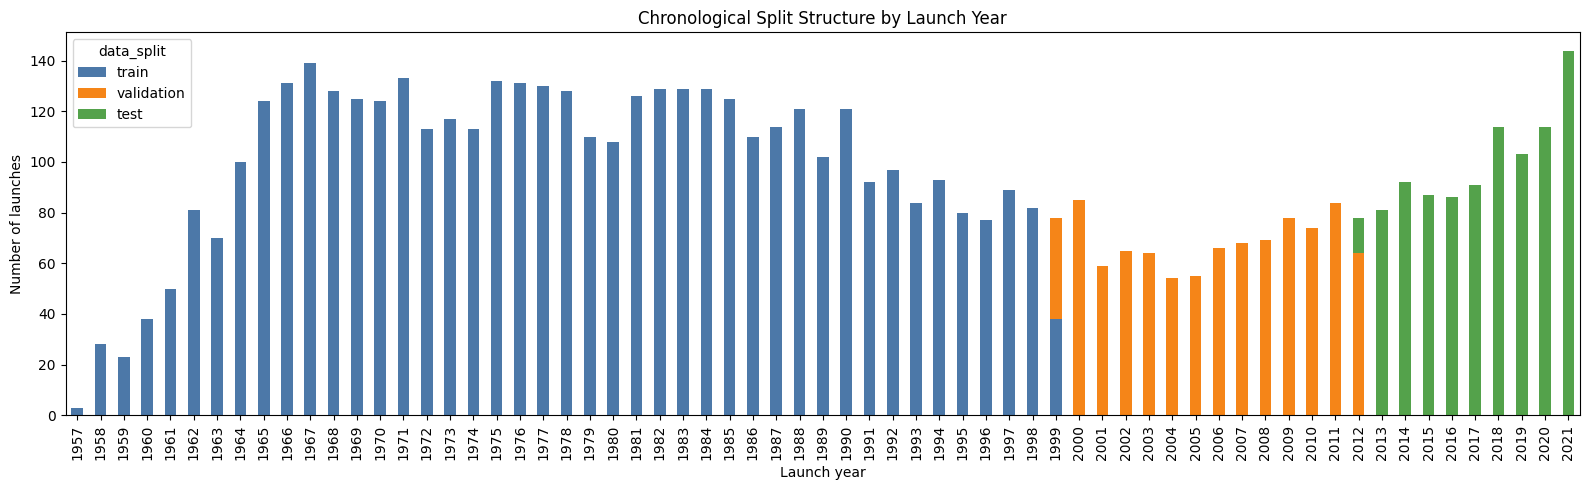

In [4]:
launches_by_year_split = (
    df.groupby(["launch_year", "data_split"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["train", "validation", "test"])
)

launches_by_year_split.plot(
    kind="bar",
    stacked=True,
    figsize=(16, 5),
    color=["#4c78a8", "#f58518", "#54a24b"],
)
plt.title("Chronological Split Structure by Launch Year")
plt.xlabel("Launch year")
plt.ylabel("Number of launches")
plt.tight_layout()
plt.show()

The output above shows that the splits are effectively chronological:

- `train` covers the earliest launches
- `validation` follows the train period
- `test` covers the latest launches

That is important because it means prior-launch features can be computed in time order
across the full table while still preserving a realistic forecasting setup.

## Define the Source Feature Pools

As in the earlier notebooks, the feature sets are defined with explicit include lists. That
makes the modeling inputs easy to audit and keeps leakage-prone or provenance-only columns
out of the pipeline.

This notebook starts from:

- a **launch source feature set**
- a broader **weather audit pool**
- a smaller **refined weather feature set** that will actually be modeled

In [5]:
launch_source_features = [
    "launch_year",
    "launch_month",
    "launch_month_name",
    "launch_quarter",
    "launch_dayofweek",
    "launch_hour_utc",
    "launch_decade",
    "Launch Suborbital",
    "is_suborbital",
    "Rocket Name",
    "Rocket Organisation",
    "company_country",
    "company_ownership",
    "Rocket Price CPI Adjusted",
    "Rocket Payload to LEO",
    "USD/kg to LEO CPI Adjusted",
    "Location",
    "Country",
    "Country_Code",
    "Operator",
    "Launch Site",
    "Comb Launch Site",
    "facility_group",
    "Lat",
    "Lon",
    "Launch Site Lat",
    "Launch Site Lon",
    "Comb Launch Site Lat",
    "Comb Launch Site Lon",
    "facility_lat",
    "facility_lon",
    "payload_count",
    "mission_mass",
    "mission_rows",
    "config_price_musd_text_parsed",
    "config_liftoff_thrust",
    "config_payload_leo",
    "config_payload_gto",
    "config_stages",
    "config_strap_ons",
    "config_rocket_height",
    "config_fairing_diameter",
    "config_fairing_height",
    "rocket_family",
]

weather_audit_features = [
    "HourlyDryBulbTemperature",
    "HourlyDewPointTemperature",
    "HourlySeaLevelPressure",
    "HourlyWindSpeed",
    "HourlyWindDirection",
    "present_weather_rain_flag",
    "present_weather_fog_flag",
    "present_weather_thunder_flag",
    "cloud_cover_broken_or_overcast_flag",
    "short_duration_precip_max",
    "HourlyStationPressure",
    "HourlyRelativeHumidity",
    "HourlyAltimeterSetting",
    "HourlyPrecipitation",
    "HourlyVisibility",
    "HourlyWindGustSpeed",
    "HourlyWetBulbTemperature",
    "HourlyPresentWeatherType",
    "HourlySkyConditions",
]

refined_weather_features = [
    "HourlyDryBulbTemperature",
    "HourlyDewPointTemperature",
    "HourlySeaLevelPressure",
    "HourlyWindSpeed",
    "HourlyWindDirection",
    "present_weather_rain_flag",
    "present_weather_fog_flag",
    "present_weather_thunder_flag",
    "cloud_cover_broken_or_overcast_flag",
    "HourlyRelativeHumidity",
    "HourlyVisibility",
]

missing_launch_features = [col for col in launch_source_features if col not in df.columns]
missing_weather_audit = [col for col in weather_audit_features if col not in df.columns]
missing_refined_weather = [col for col in refined_weather_features if col not in df.columns]

if missing_launch_features or missing_weather_audit or missing_refined_weather:
    raise ValueError(
        "Expected modeling columns are missing. "
        f"Launch missing: {missing_launch_features}. "
        f"Weather audit missing: {missing_weather_audit}. "
        f"Refined weather missing: {missing_refined_weather}."
    )

pd.DataFrame(
    {
        "feature_pool": [
            "launch_source",
            "weather_audit_pool",
            "refined_weather_for_modeling",
        ],
        "num_features": [
            len(launch_source_features),
            len(weather_audit_features),
            len(refined_weather_features),
        ],
    }
)

,feature_pool,num_features
0,launch_source,44
1,weather_audit_pool,19
2,refined_weather_for_modeling,11


## Audit the Weather Block

The earlier notebooks found that adding weather usually reduced performance slightly. Before
dropping weather entirely, this section checks whether the issue is likely to be:

- sparse coverage
- inconsistent variable quality
- too many weak or noisy weather columns entering the model at once

The modeling decision in this notebook is to keep only weather features that are both:

- reasonably interpretable
- not among the most severely missing weather variables

In [6]:
weather_missingness = (
    df[weather_audit_features]
    .isna()
    .mean()
    .mul(100)
    .rename("missing_pct")
    .sort_values(ascending=False)
    .to_frame()
)
weather_missingness["retained_for_modeling"] = weather_missingness.index.isin(refined_weather_features)

weather_missingness

,missing_pct,retained_for_modeling
HourlyWindGustSpeed,98.605707,False
short_duration_precip_max,94.763294,False
HourlyPrecipitation,94.763294,False
HourlyWetBulbTemperature,83.187419,False
HourlyAltimeterSetting,82.960441,False
HourlySkyConditions,81.290532,False
HourlyStationPressure,79.458495,False
HourlyPresentWeatherType,69.763294,False
HourlyVisibility,60.538262,True
HourlySeaLevelPressure,54.653048,True


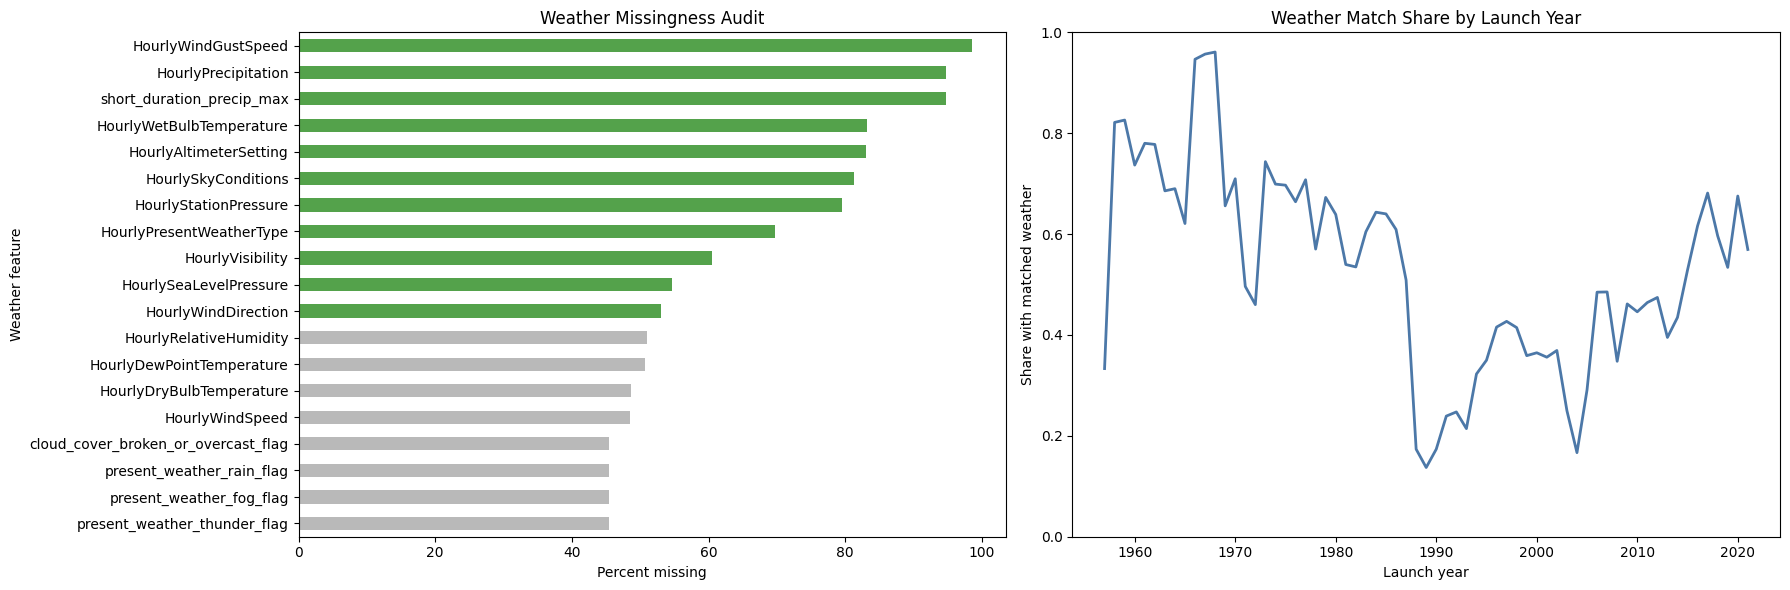

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

color_map = weather_missingness["retained_for_modeling"].map({True: "#54a24b", False: "#b9b9b9"})
weather_missingness.sort_values("missing_pct").plot(
    kind="barh",
    y="missing_pct",
    ax=axes[0],
    color=color_map,
    legend=False,
)
axes[0].set_title("Weather Missingness Audit")
axes[0].set_xlabel("Percent missing")
axes[0].set_ylabel("Weather feature")

weather_match_by_year = df.groupby("launch_year")["weather_matched"].mean()
axes[1].plot(weather_match_by_year.index, weather_match_by_year.values, color="#4c78a8", linewidth=2)
axes[1].set_title("Weather Match Share by Launch Year")
axes[1].set_xlabel("Launch year")
axes[1].set_ylabel("Share with matched weather")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [8]:
failure_rate_by_match = (
    df.groupby("weather_matched")[TARGET_COL]
    .agg(["mean", "count"])
    .rename(columns={"mean": "failure_rate", "count": "launches"})
)

failure_rate_by_match

,failure_rate,launches
weather_matched,,
False,0.084613,2801
True,0.090585,3367


The weather audit leads to a narrower weather block for modeling:

- keep core conditions such as temperature, humidity, wind, visibility, and key binary
  event flags
- drop the sparsest weather variables such as gust, precipitation amount, sky-condition
  text, and wet-bulb related fields

This is deliberately conservative. The goal is not to prove weather is decisive, but to
test whether a cleaner weather block performs better than the broader one used earlier.

## Create Row-Wise Engineered Features

The next step is a curated feature-engineering pass. These engineered variables are all
computed from information available on the same row, so they do not create leakage across
rows or splits.

The launch-derived features include:

- cyclical encodings for month, day of week, and hour
- log transforms for heavily skewed scale variables
- mission/capacity and cost/capacity ratios
- simple vehicle complexity summaries

The weather-derived features include:

- temperature spread
- wind-vector components
- threshold-style operational flags for visibility, humidity, rain, and storm signal

These are still generic weather features. A later section adds **site-relative** weather
features that ask a more contextual question: is the current weather unusual for this site
relative to what that site has historically experienced before this launch?

In [9]:
def safe_divide(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    result = numerator / denominator
    return result.replace([np.inf, -np.inf], np.nan)


def add_rowwise_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    engineered = df.copy()

    engineered["launch_month_sin"] = np.sin(2 * np.pi * engineered["launch_month"] / 12)
    engineered["launch_month_cos"] = np.cos(2 * np.pi * engineered["launch_month"] / 12)
    engineered["launch_dayofweek_sin"] = np.sin(2 * np.pi * engineered["launch_dayofweek"] / 7)
    engineered["launch_dayofweek_cos"] = np.cos(2 * np.pi * engineered["launch_dayofweek"] / 7)
    engineered["launch_hour_sin"] = np.sin(2 * np.pi * engineered["launch_hour_utc"] / 24)
    engineered["launch_hour_cos"] = np.cos(2 * np.pi * engineered["launch_hour_utc"] / 24)

    engineered["rocket_price_log"] = np.log1p(engineered["Rocket Price CPI Adjusted"].clip(lower=0))
    engineered["rocket_payload_log"] = np.log1p(engineered["Rocket Payload to LEO"].clip(lower=0))
    engineered["mission_mass_log"] = np.log1p(engineered["mission_mass"].clip(lower=0))

    engineered["payloads_per_mission_row"] = safe_divide(
        engineered["payload_count"],
        engineered["mission_rows"],
    )
    engineered["mission_mass_per_payload"] = safe_divide(
        engineered["mission_mass"],
        engineered["payload_count"],
    )
    engineered["price_per_payload_kg"] = safe_divide(
        engineered["Rocket Price CPI Adjusted"],
        engineered["Rocket Payload to LEO"],
    )
    engineered["price_per_mission_kg"] = safe_divide(
        engineered["Rocket Price CPI Adjusted"],
        engineered["mission_mass"],
    )
    engineered["thrust_to_leo_payload_ratio"] = safe_divide(
        engineered["config_liftoff_thrust"],
        engineered["config_payload_leo"],
    )
    engineered["mission_to_leo_capacity_ratio"] = safe_divide(
        engineered["mission_mass"],
        engineered["config_payload_leo"],
    )
    engineered["gto_to_leo_capacity_ratio"] = safe_divide(
        engineered["config_payload_gto"],
        engineered["config_payload_leo"],
    )
    engineered["rocket_height_to_fairing_height_ratio"] = safe_divide(
        engineered["config_rocket_height"],
        engineered["config_fairing_height"],
    )
    engineered["fairing_volume_proxy"] = (
        engineered["config_fairing_diameter"] ** 2
    ) * engineered["config_fairing_height"]
    engineered["total_stage_elements"] = (
        engineered["config_stages"].fillna(0) + engineered["config_strap_ons"].fillna(0)
    )

    engineered["temperature_dewpoint_spread"] = (
        engineered["HourlyDryBulbTemperature"] - engineered["HourlyDewPointTemperature"]
    )
    wind_direction_radians = np.deg2rad(engineered["HourlyWindDirection"])
    engineered["wind_u_component"] = engineered["HourlyWindSpeed"] * np.cos(wind_direction_radians)
    engineered["wind_v_component"] = engineered["HourlyWindSpeed"] * np.sin(wind_direction_radians)
    engineered["low_visibility_flag"] = (engineered["HourlyVisibility"].fillna(99) < 5).astype(int)
    engineered["high_humidity_flag"] = (engineered["HourlyRelativeHumidity"].fillna(-1) >= 85).astype(int)
    engineered["precipitation_any_flag"] = (
        engineered["present_weather_rain_flag"].astype(str) == "True"
    ).astype(int)
    engineered["storm_signal_flag"] = (
        (engineered["present_weather_thunder_flag"].astype(str) == "True")
        | (
            (engineered["HourlyWindSpeed"].fillna(0) >= 20)
            & (engineered["present_weather_rain_flag"].astype(str) == "True")
        )
    ).astype(int)

    return engineered

## Create Site-Relative Weather Features

A 20-knot wind or a 60% humidity reading does not necessarily mean the same thing at every
launch site. Some facilities routinely operate in weather that would be unusual elsewhere.

To capture that context, this section builds **site-relative weather features** using only
launches that occurred earlier in time at the same `facility_group`. For each site, the
notebook computes prior weather baselines and then compares the current launch weather to
those baselines.

The main feature types are:

- **anomalies**: current value minus the prior site mean
- **z-scores**: anomaly scaled by the prior site standard deviation
- **prior rates** for binary weather states such as rain or low visibility
- **unusual-weather counts** that summarize how many site-relative anomalies are large at once

These features are time-safe because every baseline is built from `shift()`ed historical
observations only. If a site does not yet have enough prior launches to support a stable
baseline, the anomaly features remain missing and are later handled by the model pipeline.

In [10]:
def add_site_relative_weather_features(df: pd.DataFrame) -> pd.DataFrame:
    site_weather = df.copy().sort_values(["launch_dt", "Launch Id"]).reset_index(drop=True)

    numeric_site_weather_cols = {
        "HourlyDryBulbTemperature": "site_temp",
        "HourlyWindSpeed": "site_windspeed",
        "HourlyRelativeHumidity": "site_humidity",
        "HourlyVisibility": "site_visibility",
        "temperature_dewpoint_spread": "site_temp_spread",
    }

    for col, prefix in numeric_site_weather_cols.items():
        group_obj = site_weather.groupby("facility_group", dropna=False)[col]
        prior_mean = group_obj.transform(lambda series: series.shift().expanding(min_periods=5).mean())
        prior_std = group_obj.transform(lambda series: series.shift().expanding(min_periods=5).std())

        site_weather[f"{prefix}_prior_mean"] = prior_mean
        site_weather[f"{prefix}_prior_std"] = prior_std
        site_weather[f"{prefix}_anomaly"] = site_weather[col] - prior_mean
        site_weather[f"{prefix}_zscore"] = safe_divide(
            site_weather[f"{prefix}_anomaly"],
            prior_std,
        )
        site_weather[f"{prefix}_abs_zscore"] = site_weather[f"{prefix}_zscore"].abs()

    binary_site_weather_cols = {
        "precipitation_any_flag": "site_precip",
        "storm_signal_flag": "site_storm",
        "low_visibility_flag": "site_low_visibility",
        "high_humidity_flag": "site_high_humidity",
    }

    for col, prefix in binary_site_weather_cols.items():
        group_obj = site_weather.groupby("facility_group", dropna=False)[col]
        prior_rate = group_obj.transform(lambda series: series.shift().expanding(min_periods=5).mean())
        site_weather[f"{prefix}_prior_rate"] = prior_rate
        site_weather[f"{prefix}_anomaly"] = site_weather[col] - prior_rate

    abs_zscore_cols = [f"{prefix}_abs_zscore" for prefix in numeric_site_weather_cols.values()]
    site_weather["site_weather_unusual_count"] = site_weather[abs_zscore_cols].ge(1.5).sum(axis=1)
    site_weather["site_weather_any_large_anomaly_flag"] = (
        site_weather["site_weather_unusual_count"] >= 1
    ).astype(int)

    return site_weather


df_engineered = add_site_relative_weather_features(add_rowwise_engineered_features(df))

In [11]:
site_relative_weather_features = [
    "site_temp_anomaly",
    "site_temp_zscore",
    "site_windspeed_anomaly",
    "site_windspeed_zscore",
    "site_humidity_anomaly",
    "site_humidity_zscore",
    "site_visibility_anomaly",
    "site_visibility_zscore",
    "site_temp_spread_anomaly",
    "site_temp_spread_zscore",
    "site_precip_prior_rate",
    "site_precip_anomaly",
    "site_storm_prior_rate",
    "site_storm_anomaly",
    "site_low_visibility_prior_rate",
    "site_low_visibility_anomaly",
    "site_high_humidity_prior_rate",
    "site_high_humidity_anomaly",
    "site_weather_unusual_count",
    "site_weather_any_large_anomaly_flag",
]

site_relative_feature_preview = (
    df_engineered[site_relative_weather_features]
    .isna()
    .mean()
    .mul(100)
    .rename("missing_pct")
    .sort_values(ascending=False)
    .to_frame()
)

site_relative_feature_preview

,missing_pct
site_visibility_zscore,62.532425
site_visibility_anomaly,61.981193
site_humidity_anomaly,52.448119
site_humidity_zscore,52.448119
site_temp_spread_anomaly,52.431907
site_temp_spread_zscore,52.431907
site_temp_zscore,50.389105
site_temp_anomaly,50.389105
site_windspeed_zscore,50.210765
site_windspeed_anomaly,50.210765


In [12]:
preview_site = df_engineered["facility_group"].mode().iloc[0]
site_relative_example = (
    df_engineered.loc[df_engineered["facility_group"] == preview_site]
    .loc[
        :,
        [
            "launch_dt",
            "facility_group",
            "HourlyDryBulbTemperature",
            "site_temp_prior_mean",
            "site_temp_anomaly",
            "HourlyWindSpeed",
            "site_windspeed_prior_mean",
            "site_windspeed_anomaly",
            "site_weather_unusual_count",
        ],
    ]
    .head(12)
)

site_relative_example

,launch_dt,facility_group,HourlyDryBulbTemperature,site_temp_prior_mean,site_temp_anomaly,HourlyWindSpeed,site_windspeed_prior_mean,site_windspeed_anomaly,site_weather_unusual_count
539,1966-03-17 10:28:00+00:00,Plesetsk Cosmodrome,18.0,NaN,NaN,2.0,NaN,NaN,0
548,1966-04-06 11:40:00+00:00,Plesetsk Cosmodrome,37.0,NaN,NaN,11.0,NaN,NaN,0
562,1966-05-17 11:00:00+00:00,Plesetsk Cosmodrome,50.0,NaN,NaN,14.0,NaN,NaN,0
577,1966-06-17 11:00:00+00:00,Plesetsk Cosmodrome,72.0,NaN,NaN,11.0,NaN,NaN,0
617,1966-10-14 12:13:00+00:00,Plesetsk Cosmodrome,32.0,NaN,NaN,5.0,NaN,NaN,0
631,1966-11-12 09:50:00+00:00,Plesetsk Cosmodrome,32.0,41.800000,-9.800000,9.0,8.600000,0.400000,0
643,1966-12-19 12:00:00+00:00,Plesetsk Cosmodrome,3.0,40.166667,-37.166667,9.0,8.666667,0.333333,2
651,1967-01-19 12:39:00+00:00,Plesetsk Cosmodrome,28.0,34.857143,-6.857143,9.0,8.714286,0.285714,0
660,1967-02-08 10:19:00+00:00,Plesetsk Cosmodrome,14.0,34.000000,-20.000000,11.0,8.750000,2.250000,0
666,1967-02-28 14:34:00+00:00,Plesetsk Cosmodrome,28.0,31.777778,-3.777778,11.0,9.000000,2.000000,0


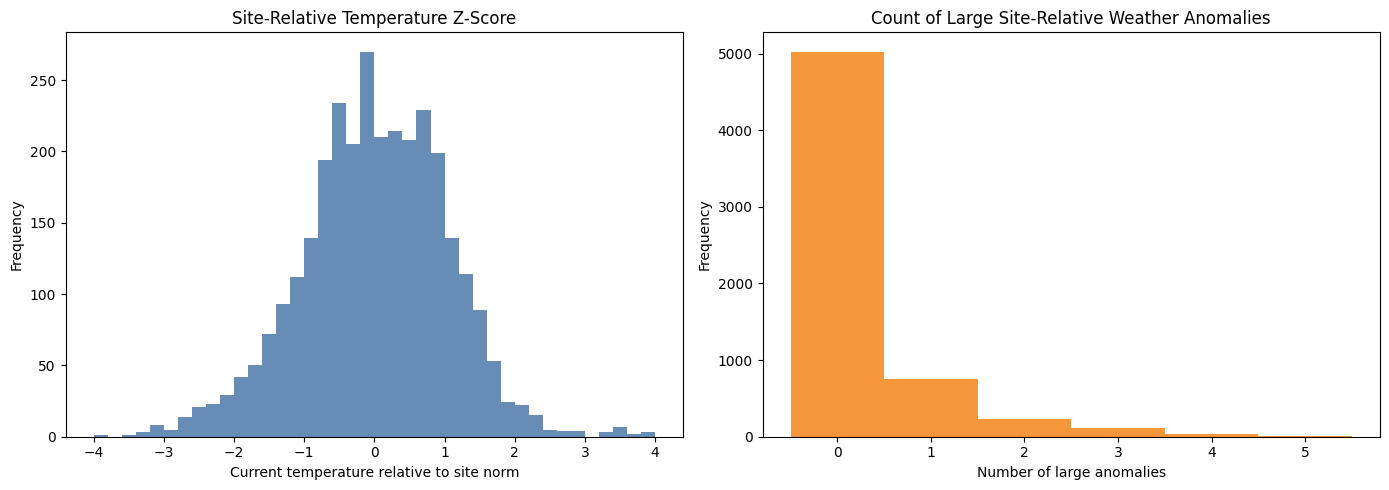

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_engineered["site_temp_zscore"].dropna().clip(-4, 4).plot(
    kind="hist",
    bins=40,
    ax=axes[0],
    color="#4c78a8",
    alpha=0.85,
)
axes[0].set_title("Site-Relative Temperature Z-Score")
axes[0].set_xlabel("Current temperature relative to site norm")

df_engineered["site_weather_unusual_count"].plot(
    kind="hist",
    bins=np.arange(-0.5, 6.5, 1),
    ax=axes[1],
    color="#f58518",
    alpha=0.85,
)
axes[1].set_title("Count of Large Site-Relative Weather Anomalies")
axes[1].set_xlabel("Number of large anomalies")

plt.tight_layout()
plt.show()

## Create Split-Safe Historical Reliability Features

This is the biggest methodological change in the notebook.

Instead of using a precomputed aggregate such as `family_success_rate_pct`, we build
rolling reliability features ourselves in chronological order. For each launch, the
historical features only use launches that happened **before** that row's timestamp.

The notebook creates prior-launch features for:

- `rocket_family`
- `Operator`
- `facility_group`

For each grouping level, we compute:

- prior launch count
- prior failure count
- prior failure rate
- days since the previous launch in that grouping

In [14]:
def add_historical_features(df: pd.DataFrame) -> pd.DataFrame:
    historical = df.copy().sort_values(["launch_dt", "Launch Id"]).reset_index(drop=True)

    for group_col, prefix in [
        ("rocket_family", "family"),
        ("Operator", "operator"),
        ("facility_group", "site"),
    ]:
        group_obj = historical.groupby(group_col, dropna=False)
        historical[f"{prefix}_prior_launch_count"] = group_obj.cumcount()
        historical[f"{prefix}_prior_failure_count"] = group_obj[TARGET_COL].cumsum() - historical[TARGET_COL]
        historical[f"{prefix}_prior_failure_rate"] = safe_divide(
            historical[f"{prefix}_prior_failure_count"],
            historical[f"{prefix}_prior_launch_count"].replace(0, np.nan),
        ).fillna(0)
        historical[f"{prefix}_days_since_last_launch"] = (
            group_obj["launch_dt"].diff().dt.total_seconds() / 86400
        )

    historical["global_prior_launch_count"] = np.arange(len(historical))
    historical["global_prior_failure_count"] = historical[TARGET_COL].cumsum() - historical[TARGET_COL]
    historical["global_prior_failure_rate"] = safe_divide(
        historical["global_prior_failure_count"],
        historical["global_prior_launch_count"].replace(0, np.nan),
    ).fillna(0)

    return historical


df_engineered = add_historical_features(df_engineered)

In [15]:
engineered_launch_features = [
    "launch_month_sin",
    "launch_month_cos",
    "launch_dayofweek_sin",
    "launch_dayofweek_cos",
    "launch_hour_sin",
    "launch_hour_cos",
    "rocket_price_log",
    "rocket_payload_log",
    "mission_mass_log",
    "payloads_per_mission_row",
    "mission_mass_per_payload",
    "price_per_payload_kg",
    "price_per_mission_kg",
    "thrust_to_leo_payload_ratio",
    "mission_to_leo_capacity_ratio",
    "gto_to_leo_capacity_ratio",
    "rocket_height_to_fairing_height_ratio",
    "fairing_volume_proxy",
    "total_stage_elements",
]

historical_features = [
    "family_prior_launch_count",
    "family_prior_failure_count",
    "family_prior_failure_rate",
    "family_days_since_last_launch",
    "operator_prior_launch_count",
    "operator_prior_failure_count",
    "operator_prior_failure_rate",
    "operator_days_since_last_launch",
    "site_prior_launch_count",
    "site_prior_failure_count",
    "site_prior_failure_rate",
    "site_days_since_last_launch",
    "global_prior_launch_count",
    "global_prior_failure_count",
    "global_prior_failure_rate",
]

engineered_weather_features = [
    "temperature_dewpoint_spread",
    "wind_u_component",
    "wind_v_component",
    "low_visibility_flag",
    "high_humidity_flag",
    "precipitation_any_flag",
    "storm_signal_flag",
]

launch_model_features = (
    launch_source_features
    + engineered_launch_features
    + historical_features
)
weather_model_features = (
    launch_model_features
    + refined_weather_features
    + engineered_weather_features
    + site_relative_weather_features
)

pd.DataFrame(
    {
        "feature_set": [
            "launch_only_with_history",
            "launch_plus_refined_weather_with_history",
        ],
        "num_features": [
            len(launch_model_features),
            len(weather_model_features),
        ],
    }
)

,feature_set,num_features
0,launch_only_with_history,78
1,launch_plus_refined_weather_with_history,116


In [16]:
most_common_family = df_engineered["rocket_family"].value_counts().idxmax()
history_example = (
    df_engineered.loc[df_engineered["rocket_family"] == most_common_family]
    .loc[
        :,
        [
            "launch_dt",
            "rocket_family",
            TARGET_COL,
            "family_prior_launch_count",
            "family_prior_failure_count",
            "family_prior_failure_rate",
            "family_days_since_last_launch",
        ],
    ]
    .head(10)
)

history_example

,launch_dt,rocket_family,is_failure_or_partial,family_prior_launch_count,family_prior_failure_count,family_prior_failure_rate,family_days_since_last_launch
1440,1973-05-18 11:00:00+00:00,Soyuz U,0,0,0,0.000000,NaN
1483,1973-09-21 13:05:00+00:00,Soyuz U,0,1,0,0.000000,126.086806
1500,1973-10-31 18:24:00+00:00,Soyuz U,0,2,0,0.000000,40.221528
1543,1974-03-20 08:30:00+00:00,Soyuz U,0,3,0,0.000000,139.587500
1545,1974-04-03 07:30:00+00:00,Soyuz U,0,4,0,0.000000,13.958333
1558,1974-05-15 08:30:00+00:00,Soyuz U,0,5,0,0.000000,42.041667
1564,1974-05-23 12:16:00+00:00,Soyuz U,1,6,0,0.000000,8.156944
1592,1974-08-06 00:02:00+00:00,Soyuz U,0,7,1,0.142857,74.490278
1595,1974-08-12 06:25:00+00:00,Soyuz U,0,8,1,0.125000,6.265972
1612,1974-10-22 17:59:00+00:00,Soyuz U,0,9,1,0.111111,71.481944


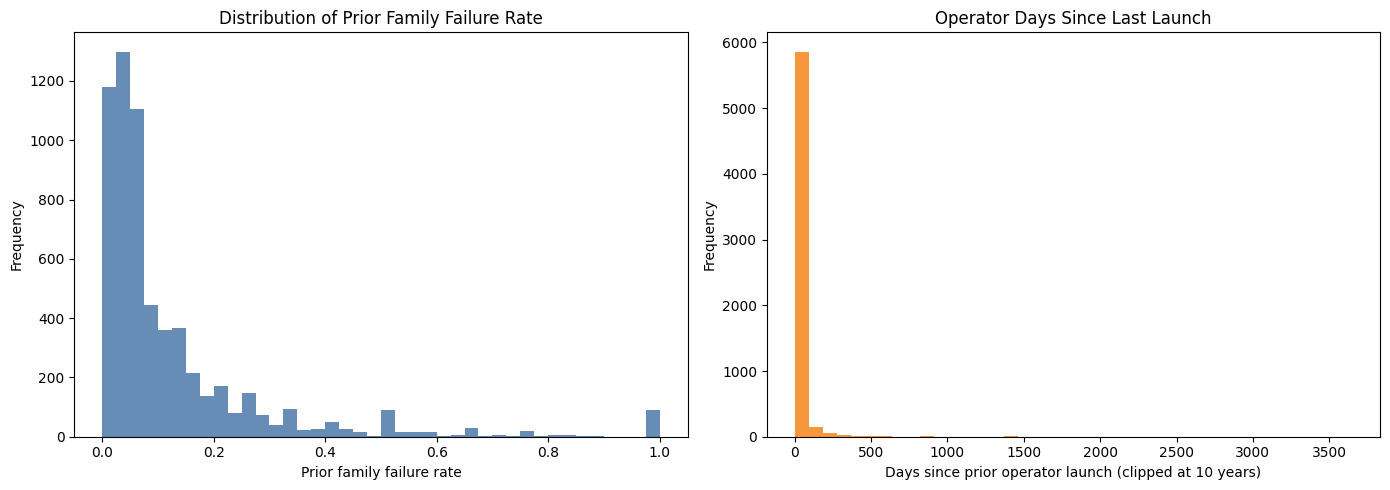

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_engineered["family_prior_failure_rate"].plot(
    kind="hist",
    bins=40,
    ax=axes[0],
    color="#4c78a8",
    alpha=0.85,
)
axes[0].set_title("Distribution of Prior Family Failure Rate")
axes[0].set_xlabel("Prior family failure rate")

df_engineered["operator_days_since_last_launch"].dropna().clip(upper=3650).plot(
    kind="hist",
    bins=40,
    ax=axes[1],
    color="#f58518",
    alpha=0.85,
)
axes[1].set_title("Operator Days Since Last Launch")
axes[1].set_xlabel("Days since prior operator launch (clipped at 10 years)")

plt.tight_layout()
plt.show()

## Create Split DataFrames

The feature engineering has changed the columns, but the train/validation/test logic stays
the same as in the earlier notebooks. All model selection still happens using the provided
chronological split.

In [18]:
train_mask = df_engineered["data_split"].eq("train")
val_mask = df_engineered["data_split"].eq("validation")
test_mask = df_engineered["data_split"].eq("test")
trainval_mask = df_engineered["data_split"].isin(["train", "validation"])

y_train = df_engineered.loc[train_mask, TARGET_COL]
y_val = df_engineered.loc[val_mask, TARGET_COL]
y_test = df_engineered.loc[test_mask, TARGET_COL]
y_trainval = df_engineered.loc[trainval_mask, TARGET_COL]

split_data = {
    "Launch-Only": {
        "X_train": df_engineered.loc[train_mask, launch_model_features],
        "X_val": df_engineered.loc[val_mask, launch_model_features],
        "X_test": df_engineered.loc[test_mask, launch_model_features],
        "X_trainval": df_engineered.loc[trainval_mask, launch_model_features],
    },
    "Launch + Weather": {
        "X_train": df_engineered.loc[train_mask, weather_model_features],
        "X_val": df_engineered.loc[val_mask, weather_model_features],
        "X_test": df_engineered.loc[test_mask, weather_model_features],
        "X_trainval": df_engineered.loc[trainval_mask, weather_model_features],
    },
}

{
    name: {split_name: split_df.shape for split_name, split_df in parts.items()}
    for name, parts in split_data.items()
}

{'Launch-Only': {'X_train': (4317, 78),
  'X_val': (925, 78),
  'X_test': (926, 78),
  'X_trainval': (5242, 78)},
 'Launch + Weather': {'X_train': (4317, 116),
  'X_val': (925, 116),
  'X_test': (926, 116),
  'X_trainval': (5242, 116)}}

## Modeling Helpers

The model family remains random forest so the results stay comparable to the earlier
notebooks. The biggest workflow changes are:

- tune hyperparameters using **average precision** rather than ROC AUC so model selection is
  more aligned with minority-class detection
- evaluate multiple threshold choices on validation instead of accepting the default `0.5`
- report top-decile capture as a ranking-oriented business metric

In [19]:
def build_pipeline(X: pd.DataFrame, rf_params: dict | None = None) -> Pipeline:
    rf_params = rf_params or {}

    numeric_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_cols = [col for col in X.columns if col not in numeric_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                    ]
                ),
                numeric_cols,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
                        (
                            "to_string",
                            FunctionTransformer(
                                lambda data: data.astype(str),
                                feature_names_out="one-to-one",
                            ),
                        ),
                        (
                            "onehot",
                            OneHotEncoder(
                                handle_unknown="ignore",
                                sparse_output=False,
                            ),
                        ),
                    ]
                ),
                categorical_cols,
            ),
        ]
    )

    model_defaults = {
        "n_estimators": 400,
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "class_weight": "balanced_subsample",
    }
    model_defaults.update(rf_params)

    model = RandomForestClassifier(**model_defaults)

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )


def run_random_search(X_train: pd.DataFrame, X_val: pd.DataFrame, y_train: pd.Series, y_val: pd.Series):
    X_dev = pd.concat([X_train, X_val], axis=0)
    y_dev = pd.concat([y_train, y_val], axis=0)
    split_index = np.r_[np.full(len(X_train), -1), np.zeros(len(X_val), dtype=int)]
    predefined_split = PredefinedSplit(test_fold=split_index)

    param_distributions = {
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [None, 12, 16, 24],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4, 8],
        "model__max_features": ["sqrt", "log2", 0.4],
        "model__max_leaf_nodes": [32, 64, 128, None],
        "model__class_weight": ["balanced", "balanced_subsample"],
    }

    search = RandomizedSearchCV(
        estimator=build_pipeline(X_train),
        param_distributions=param_distributions,
        n_iter=12,
        scoring="average_precision",
        cv=predefined_split,
        random_state=RANDOM_STATE,
        n_jobs=1,
        refit=False,
        verbose=0,
    )
    search.fit(X_dev, y_dev)

    best_params = {key.replace("model__", ""): value for key, value in search.best_params_.items()}

    search_results = (
        pd.DataFrame(search.cv_results_)
        .sort_values("rank_test_score")
        .loc[
            :,
            [
                "rank_test_score",
                "mean_test_score",
                "param_model__n_estimators",
                "param_model__max_depth",
                "param_model__min_samples_split",
                "param_model__min_samples_leaf",
                "param_model__max_features",
                "param_model__max_leaf_nodes",
                "param_model__class_weight",
            ],
        ]
        .rename(columns={"mean_test_score": "validation_average_precision"})
    )
    search_results["validation_average_precision"] = search_results["validation_average_precision"].round(4)

    return best_params, search_results


def fit_model(X_train: pd.DataFrame, y_train: pd.Series, rf_params: dict | None = None):
    model = build_pipeline(X_train, rf_params=rf_params)
    model.fit(X_train, y_train)
    return model


def top_decile_capture(y_true: pd.Series, scores: np.ndarray, share: float = 0.10) -> float:
    ranked = pd.DataFrame({"y_true": y_true.to_numpy(), "score": scores}).sort_values("score", ascending=False)
    cutoff = max(1, int(np.ceil(len(ranked) * share)))
    captured_failures = ranked.head(cutoff)["y_true"].sum()
    total_failures = ranked["y_true"].sum()
    if total_failures == 0:
        return np.nan
    return captured_failures / total_failures


def threshold_metrics(y_true: pd.Series, scores: np.ndarray, threshold: float, model_name: str, split_name: str, operating_point: str):
    y_pred = (scores >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    return {
        "model": model_name,
        "split": split_name,
        "operating_point": operating_point,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "failure_precision": precision_score(y_true, y_pred, zero_division=0),
        "failure_recall": recall_score(y_true, y_pred, zero_division=0),
        "success_recall": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, scores),
        "average_precision": average_precision_score(y_true, scores),
        "brier_score": brier_score_loss(y_true, scores),
        "top_decile_capture": top_decile_capture(y_true, scores),
        "tn": cm[0, 0],
        "fp": cm[0, 1],
        "fn": cm[1, 0],
        "tp": cm[1, 1],
    }


def metrics_frame(metric_rows: list[dict]) -> pd.DataFrame:
    metric_cols = [
        "threshold",
        "accuracy",
        "balanced_accuracy",
        "failure_precision",
        "failure_recall",
        "success_recall",
        "f1",
        "roc_auc",
        "average_precision",
        "brier_score",
        "top_decile_capture",
    ]
    out = pd.DataFrame(metric_rows)
    out[metric_cols] = out[metric_cols].round(4)
    return out


def operating_point_table(y_true: pd.Series, scores: np.ndarray, model_name: str, precision_floor: float = 0.25) -> pd.DataFrame:
    precision_curve, recall_curve, thresholds = precision_recall_curve(y_true, scores)

    candidate_thresholds = np.unique(
        np.clip(
            np.r_[0.5, thresholds],
            0,
            1,
        )
    )

    rows = []
    for threshold in candidate_thresholds:
        y_pred = (scores >= threshold).astype(int)
        rows.append(
            {
                "threshold": threshold,
                "failure_precision": precision_score(y_true, y_pred, zero_division=0),
                "failure_recall": recall_score(y_true, y_pred, zero_division=0),
                "f1": f1_score(y_true, y_pred, zero_division=0),
                "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            }
        )

    threshold_df = pd.DataFrame(rows).drop_duplicates(subset=["threshold"]).sort_values("threshold").reset_index(drop=True)

    default_row = threshold_df.iloc[(threshold_df["threshold"] - 0.5).abs().argmin()].copy()
    default_row["operating_point"] = "default_0_50"

    best_f1_row = threshold_df.sort_values(["f1", "balanced_accuracy"], ascending=False).iloc[0].copy()
    best_f1_row["operating_point"] = "best_validation_f1"

    precision_floor_df = threshold_df.loc[threshold_df["failure_precision"] >= precision_floor]
    if precision_floor_df.empty:
        precision_floor_row = threshold_df.sort_values(["failure_precision", "failure_recall"], ascending=False).iloc[0].copy()
        precision_floor_row["operating_point"] = f"best_available_precision_floor_{precision_floor:.2f}"
    else:
        precision_floor_row = precision_floor_df.sort_values(
            ["failure_recall", "f1", "balanced_accuracy"],
            ascending=False,
        ).iloc[0].copy()
        precision_floor_row["operating_point"] = f"max_recall_at_precision_{precision_floor:.2f}"

    operating_points = pd.DataFrame([default_row, best_f1_row, precision_floor_row])
    operating_points.insert(0, "model", model_name)

    numeric_cols = ["threshold", "failure_precision", "failure_recall", "f1", "balanced_accuracy"]
    operating_points[numeric_cols] = operating_points[numeric_cols].round(4)
    return operating_points


def get_feature_importance_frame(model: Pipeline, top_n: int = 15) -> pd.DataFrame:
    feature_names = model.named_steps["preprocessor"].get_feature_names_out()
    importances = model.named_steps["model"].feature_importances_
    importance_df = pd.DataFrame(
        {
            "feature": feature_names,
            "importance": importances,
        }
    ).sort_values("importance", ascending=False)
    return importance_df.head(top_n)


def get_source_feature_importance_frame(model: Pipeline) -> pd.DataFrame:
    preprocessor = model.named_steps["preprocessor"]
    importances = model.named_steps["model"].feature_importances_

    rows = []
    position = 0

    for transformer_name, transformer, columns in preprocessor.transformers_:
        if transformer_name == "remainder":
            continue

        if transformer_name == "num":
            for col in columns:
                rows.append({"source_feature": col, "importance": importances[position]})
                position += 1

        elif transformer_name == "cat":
            onehot = transformer.named_steps["onehot"]
            for col, categories in zip(columns, onehot.categories_):
                width = len(categories)
                rows.append(
                    {
                        "source_feature": col,
                        "importance": importances[position: position + width].sum(),
                    }
                )
                position += width

    return (
        pd.DataFrame(rows)
        .groupby("source_feature", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )


def subset_validation_metrics(
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    y_train: pd.Series,
    y_val: pd.Series,
    rf_params: dict,
    subset_name: str,
) -> dict:
    subset_model = fit_model(X_train, y_train, rf_params=rf_params)
    subset_scores = subset_model.predict_proba(X_val)[:, 1]
    subset_pred = (subset_scores >= 0.5).astype(int)

    return {
        "weather_subset": subset_name,
        "num_weather_features": X_train.shape[1] - len(launch_model_features),
        "validation_average_precision": average_precision_score(y_val, subset_scores),
        "validation_roc_auc": roc_auc_score(y_val, subset_scores),
        "validation_failure_precision": precision_score(y_val, subset_pred, zero_division=0),
        "validation_failure_recall": recall_score(y_val, subset_pred, zero_division=0),
        "validation_f1": f1_score(y_val, subset_pred, zero_division=0),
        "validation_balanced_accuracy": balanced_accuracy_score(y_val, subset_pred),
        "validation_top_decile_capture": top_decile_capture(y_val, subset_scores),
    }

## Tune the Two Models Using Validation Average Precision

The earlier notebooks selected models using ROC AUC. That is still useful, but for an
imbalanced failure-detection problem, average precision is a better tuning target because it
reflects how well the model concentrates actual failures near the top of its risk ranking.

In [20]:
launch_best_params, launch_search_results = run_random_search(
    split_data["Launch-Only"]["X_train"],
    split_data["Launch-Only"]["X_val"],
    y_train,
    y_val,
)

weather_best_params, weather_search_results = run_random_search(
    split_data["Launch + Weather"]["X_train"],
    split_data["Launch + Weather"]["X_val"],
    y_train,
    y_val,
)

pd.DataFrame(
    [
        {"model": "Launch-Only", **launch_best_params},
        {"model": "Launch + Weather", **weather_best_params},
    ]
)

,model,n_estimators,min_samples_split,min_samples_leaf,max_leaf_nodes,max_features,max_depth,class_weight
0,Launch-Only,600,5,8,NaN,0.4,12,balanced
1,Launch + Weather,600,5,2,128.0,0.4,16,balanced


In [21]:
print("Top launch-only candidates ranked by validation average precision:")
display(launch_search_results.head(5))

print("Top launch + weather candidates ranked by validation average precision:")
display(weather_search_results.head(5))

Top launch-only candidates ranked by validation average precision:


,rank_test_score,validation_average_precision,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features,param_model__max_leaf_nodes,param_model__class_weight
1,1,0.3221,600,12,5,8,0.4,None,balanced
2,2,0.3130,400,16,10,8,0.4,None,balanced
10,3,0.3086,200,None,10,1,0.4,64,balanced
6,4,0.3076,200,24,2,4,0.4,64,balanced
9,5,0.2877,600,16,5,2,0.4,128,balanced


Top launch + weather candidates ranked by validation average precision:


,rank_test_score,validation_average_precision,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features,param_model__max_leaf_nodes,param_model__class_weight
9,1,0.2871,600,16,5,2,0.4,128,balanced
1,2,0.2850,600,12,5,8,0.4,None,balanced
2,3,0.2807,400,16,10,8,0.4,None,balanced
5,4,0.2751,600,24,5,8,sqrt,64,balanced_subsample
6,5,0.2723,200,24,2,4,0.4,64,balanced


## Narrow the Weather Field

The earlier notebooks suggested that weather may contain some signal, but that the full
weather block might still be too noisy. This section tests that idea directly.

The workflow is:

1. fit the tuned full weather model on the training split
2. aggregate feature importance back to the original weather source columns
3. define several smaller weather subsets
4. compare those subsets on the validation split while holding the launch features fixed

The subset comparison uses the same tuned random forest hyperparameters for every weather
subset. That is intentional: it isolates the effect of the weather feature block itself
rather than mixing feature-selection effects with another round of hyperparameter search.

In [22]:
full_weather_validation_model = fit_model(
    split_data["Launch + Weather"]["X_train"],
    y_train,
    rf_params=weather_best_params,
)

weather_source_importances = (
    get_source_feature_importance_frame(full_weather_validation_model)
    .loc[
        lambda frame: frame["source_feature"].isin(
            refined_weather_features + engineered_weather_features + site_relative_weather_features
        )
    ]
    .reset_index(drop=True)
)

weather_source_importances.head(20)

,source_feature,importance
0,site_high_humidity_anomaly,0.014616
1,HourlySeaLevelPressure,0.011148
2,site_precip_prior_rate,0.009876
3,site_temp_spread_anomaly,0.009715
4,site_temp_spread_zscore,0.009654
5,site_humidity_zscore,0.009642
6,site_humidity_anomaly,0.009639
7,HourlyWindDirection,0.009401
8,site_low_visibility_anomaly,0.009337
9,site_precip_anomaly,0.009281


In [23]:
top_5_weather_features = weather_source_importances.head(5)["source_feature"].tolist()
top_10_weather_features = weather_source_importances.head(10)["source_feature"].tolist()
top_15_weather_features = weather_source_importances.head(15)["source_feature"].tolist()

weather_feature_subsets = {
    "full_weather_block": refined_weather_features + engineered_weather_features + site_relative_weather_features,
    "raw_weather_only": refined_weather_features,
    "engineered_weather_only": engineered_weather_features,
    "site_relative_weather_only": site_relative_weather_features,
    "top_5_weather_features": top_5_weather_features,
    "top_10_weather_features": top_10_weather_features,
    "top_15_weather_features": top_15_weather_features,
}

weather_subset_validation_rows = []
for subset_name, subset_weather_features in weather_feature_subsets.items():
    subset_train = df_engineered.loc[train_mask, launch_model_features + subset_weather_features]
    subset_val = df_engineered.loc[val_mask, launch_model_features + subset_weather_features]

    weather_subset_validation_rows.append(
        subset_validation_metrics(
            subset_train,
            subset_val,
            y_train,
            y_val,
            rf_params=weather_best_params,
            subset_name=subset_name,
        )
    )

weather_subset_validation_results = pd.DataFrame(weather_subset_validation_rows)
metric_cols = [
    "validation_average_precision",
    "validation_roc_auc",
    "validation_failure_precision",
    "validation_failure_recall",
    "validation_f1",
    "validation_balanced_accuracy",
    "validation_top_decile_capture",
]
weather_subset_validation_results[metric_cols] = weather_subset_validation_results[metric_cols].round(4)

weather_subset_validation_results.sort_values(
    ["validation_average_precision", "validation_roc_auc"],
    ascending=False,
)

,weather_subset,num_weather_features,validation_average_precision,validation_roc_auc,validation_failure_precision,validation_failure_recall,validation_f1,validation_balanced_accuracy,validation_top_decile_capture
1,raw_weather_only,11,0.3156,0.7619,0.3704,0.3509,0.3604,0.6559,0.4211
5,top_10_weather_features,10,0.3149,0.7592,0.3333,0.3684,0.3500,0.6600,0.4386
3,site_relative_weather_only,20,0.3059,0.7590,0.3636,0.3509,0.3571,0.6553,0.4035
4,top_5_weather_features,5,0.3053,0.7538,0.3600,0.3158,0.3364,0.6395,0.4211
2,engineered_weather_only,7,0.2998,0.7535,0.3393,0.3333,0.3363,0.6454,0.4035
6,top_15_weather_features,15,0.2890,0.7528,0.3030,0.3509,0.3252,0.6489,0.4386
0,full_weather_block,38,0.2871,0.7532,0.3333,0.3860,0.3577,0.6676,0.3860


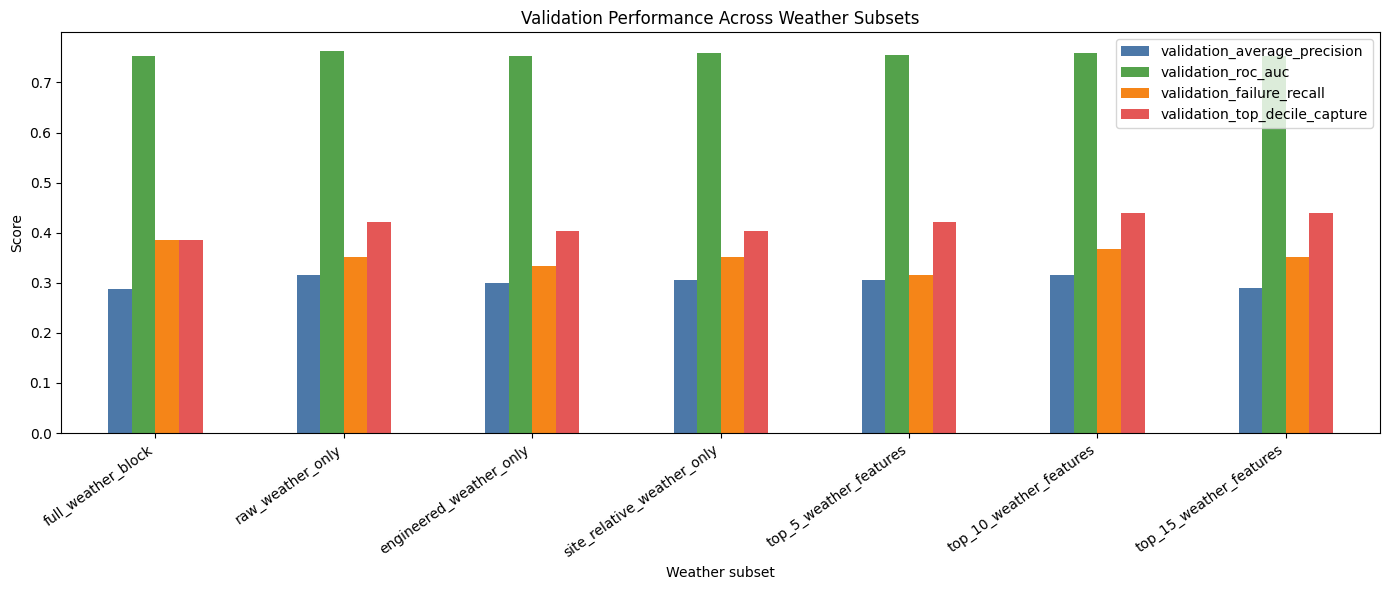

In [24]:
weather_subset_validation_results.set_index("weather_subset")[
    [
        "validation_average_precision",
        "validation_roc_auc",
        "validation_failure_recall",
        "validation_top_decile_capture",
    ]
].plot(
    kind="bar",
    figsize=(14, 6),
    color=["#4c78a8", "#54a24b", "#f58518", "#e45756"],
)
plt.title("Validation Performance Across Weather Subsets")
plt.xlabel("Weather subset")
plt.ylabel("Score")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [25]:
selected_weather_subset_name = (
    weather_subset_validation_results
    .sort_values(["validation_average_precision", "validation_roc_auc"], ascending=False)
    .iloc[0]["weather_subset"]
)
selected_weather_only_features = weather_feature_subsets[selected_weather_subset_name]
selected_weather_model_features = launch_model_features + selected_weather_only_features

print("Selected weather subset:", selected_weather_subset_name)
print("Selected weather-only features:")
print(selected_weather_only_features)

split_data["Launch + Weather"] = {
    "X_train": df_engineered.loc[train_mask, selected_weather_model_features],
    "X_val": df_engineered.loc[val_mask, selected_weather_model_features],
    "X_test": df_engineered.loc[test_mask, selected_weather_model_features],
    "X_trainval": df_engineered.loc[trainval_mask, selected_weather_model_features],
}

Selected weather subset: raw_weather_only
Selected weather-only features:
['HourlyDryBulbTemperature', 'HourlyDewPointTemperature', 'HourlySeaLevelPressure', 'HourlyWindSpeed', 'HourlyWindDirection', 'present_weather_rain_flag', 'present_weather_fog_flag', 'present_weather_thunder_flag', 'cloud_cover_broken_or_overcast_flag', 'HourlyRelativeHumidity', 'HourlyVisibility']


## Fit the Tuned Validation Models

Once the best hyperparameters are selected, the tuned models are fit on the `train` split
so they can be judged cleanly on the `validation` split before touching the test data.

In [26]:
validation_models = {
    "Launch-Only": fit_model(
        split_data["Launch-Only"]["X_train"],
        y_train,
        rf_params=launch_best_params,
    ),
    "Launch + Weather": fit_model(
        split_data["Launch + Weather"]["X_train"],
        y_train,
        rf_params=weather_best_params,
    ),
}

validation_scores = {
    model_name: model.predict_proba(split_data[model_name]["X_val"])[:, 1]
    for model_name, model in validation_models.items()
}

## Validation Ranking Performance

This table evaluates both models at the default `0.5` threshold, but it also includes the
ranking-oriented metrics that matter most here:

- ROC AUC
- average precision
- top-decile failure capture

In [27]:
validation_default_metrics = metrics_frame(
    [
        threshold_metrics(
            y_val,
            validation_scores["Launch-Only"],
            threshold=0.5,
            model_name="Launch-Only",
            split_name="validation",
            operating_point="default_0_50",
        ),
        threshold_metrics(
            y_val,
            validation_scores["Launch + Weather"],
            threshold=0.5,
            model_name="Launch + Weather",
            split_name="validation",
            operating_point="default_0_50",
        ),
    ]
)

validation_default_metrics.sort_values(["average_precision", "roc_auc"], ascending=False)

,model,split,operating_point,threshold,accuracy,balanced_accuracy,failure_precision,failure_recall,success_recall,f1,roc_auc,average_precision,brier_score,top_decile_capture,tn,fp,fn,tp
0,Launch-Only,validation,default_0_50,0.5,0.8800,0.6738,0.2404,0.4386,0.9090,0.3106,0.7651,0.3221,0.1366,0.4035,789,79,32,25
1,Launch + Weather,validation,default_0_50,0.5,0.9232,0.6559,0.3704,0.3509,0.9608,0.3604,0.7619,0.3156,0.1103,0.4211,834,34,37,20


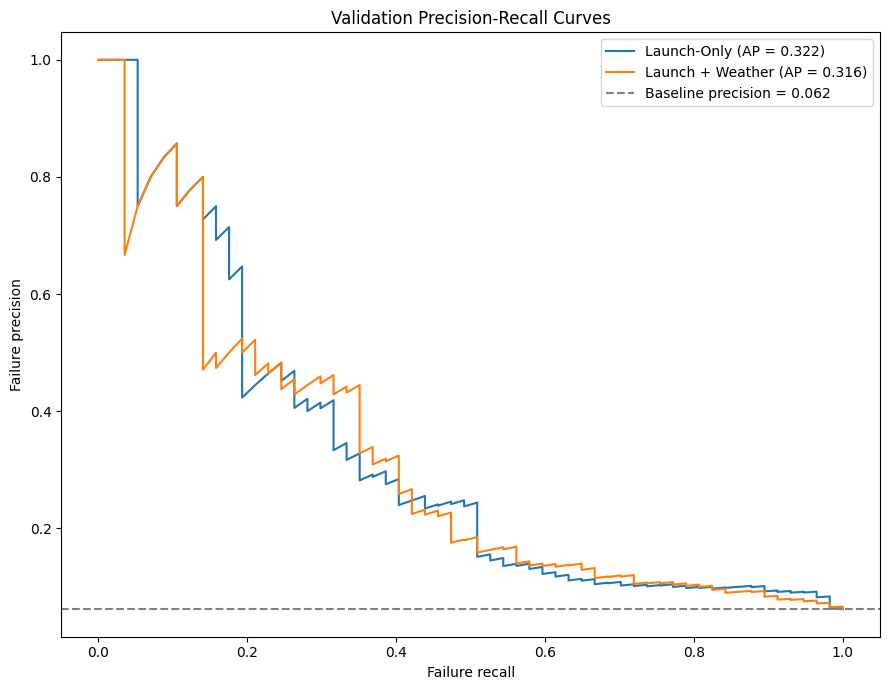

In [28]:
plt.figure(figsize=(9, 7))
for model_name, scores in validation_scores.items():
    precision_curve, recall_curve, _ = precision_recall_curve(y_val, scores)
    avg_precision = average_precision_score(y_val, scores)
    plt.plot(recall_curve, precision_curve, label=f"{model_name} (AP = {avg_precision:.3f})")

baseline_precision = y_val.mean()
plt.axhline(baseline_precision, linestyle="--", color="gray", label=f"Baseline precision = {baseline_precision:.3f}")
plt.xlabel("Failure recall")
plt.ylabel("Failure precision")
plt.title("Validation Precision-Recall Curves")
plt.legend()
plt.tight_layout()
plt.show()

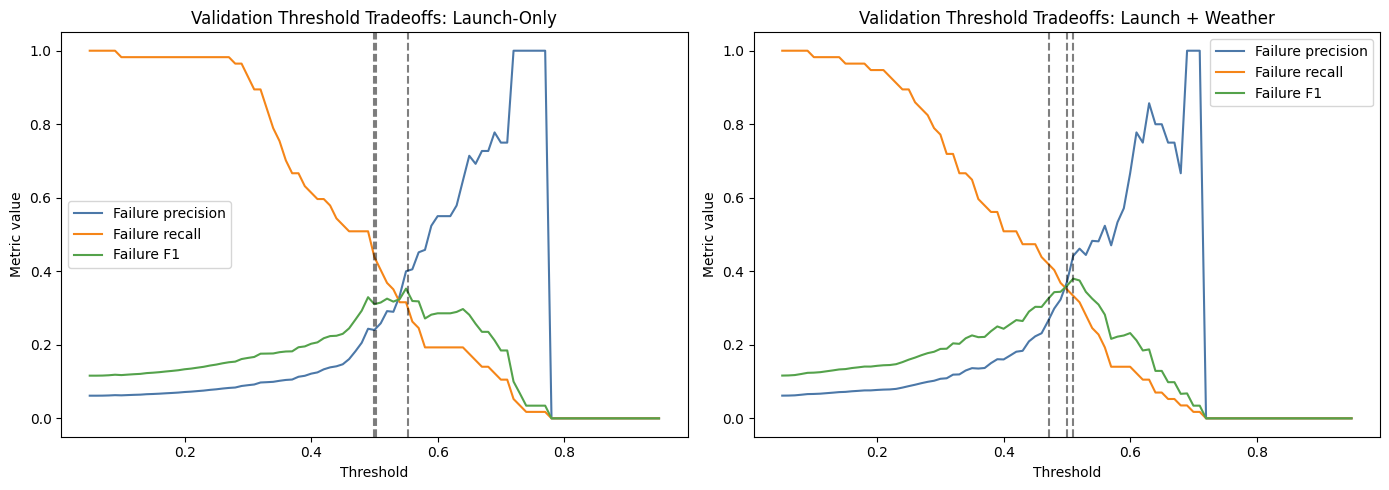

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model_name in zip(axes, ["Launch-Only", "Launch + Weather"]):
    threshold_table = operating_point_table(y_val, validation_scores[model_name], model_name=model_name)
    threshold_grid = np.linspace(0.05, 0.95, 91)
    curve_rows = []

    for threshold in threshold_grid:
        y_pred = (validation_scores[model_name] >= threshold).astype(int)
        curve_rows.append(
            {
                "threshold": threshold,
                "failure_precision": precision_score(y_val, y_pred, zero_division=0),
                "failure_recall": recall_score(y_val, y_pred, zero_division=0),
                "f1": f1_score(y_val, y_pred, zero_division=0),
            }
        )

    curve_df = pd.DataFrame(curve_rows)
    ax.plot(curve_df["threshold"], curve_df["failure_precision"], label="Failure precision", color="#4c78a8")
    ax.plot(curve_df["threshold"], curve_df["failure_recall"], label="Failure recall", color="#f58518")
    ax.plot(curve_df["threshold"], curve_df["f1"], label="Failure F1", color="#54a24b")

    for _, row in threshold_table.iterrows():
        ax.axvline(row["threshold"], linestyle="--", alpha=0.5, color="black")

    ax.set_title(f"Validation Threshold Tradeoffs: {model_name}")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Metric value")
    ax.legend()

plt.tight_layout()
plt.show()

## Validation Threshold Selection

Threshold tuning is not about changing the ranking ability of the model. ROC AUC and average
precision stay the same. Threshold tuning is about choosing the operating point that best
matches the project goal.

This notebook keeps three operating points for each model:

- `default_0_50`
- `best_validation_f1`
- `max_recall_at_precision_0.25`

The last option is intentionally practical: it looks for the most recall the model can
achieve while keeping failure precision at or above `0.25`.

In [30]:
validation_operating_points = pd.concat(
    [
        operating_point_table(y_val, validation_scores["Launch-Only"], model_name="Launch-Only", precision_floor=0.25),
        operating_point_table(y_val, validation_scores["Launch + Weather"], model_name="Launch + Weather", precision_floor=0.25),
    ],
    ignore_index=True,
)

validation_operating_points

,model,threshold,failure_precision,failure_recall,f1,balanced_accuracy,operating_point
0,Launch-Only,0.5000,0.2404,0.4386,0.3106,0.6738,default_0_50
1,Launch-Only,0.5529,0.4186,0.3158,0.3600,0.6435,best_validation_f1
2,Launch-Only,0.5028,0.2551,0.4386,0.3226,0.6772,max_recall_at_precision_0.25
3,Launch + Weather,0.5000,0.3704,0.3509,0.3604,0.6559,default_0_50
4,Launch + Weather,0.5094,0.4444,0.3509,0.3922,0.6610,best_validation_f1
5,Launch + Weather,0.4716,0.2667,0.4211,0.3265,0.6725,max_recall_at_precision_0.25


Based on validation ranking metrics, the **Launch-Only** model is the preferred primary
model:

- it has the higher validation average precision
- it has the higher validation ROC AUC
- it is simpler and avoids relying on a weather block that has been unstable across notebooks

The weather model is still kept in the analysis because the refined weather audit makes it
more competitive than before, and the comparison remains useful.

## Refit Final Models on Train + Validation

After choosing the hyperparameters and validation thresholds, the final model versions are
fit on the combined `train + validation` rows. The thresholds themselves stay fixed from the
validation analysis.

In [31]:
final_models = {
    "Launch-Only": fit_model(
        split_data["Launch-Only"]["X_trainval"],
        y_trainval,
        rf_params=launch_best_params,
    ),
    "Launch + Weather": fit_model(
        split_data["Launch + Weather"]["X_trainval"],
        y_trainval,
        rf_params=weather_best_params,
    ),
}

test_scores = {
    model_name: model.predict_proba(split_data[model_name]["X_test"])[:, 1]
    for model_name, model in final_models.items()
}

## Test Results at the Validation-Selected Thresholds

This is the main holdout evaluation for the notebook. It answers two different questions:

- how do the two models rank failure risk overall?
- what happens when the validation-selected operating thresholds are applied to truly unseen data?

In [32]:
test_metric_rows = []
validation_threshold_lookup = (
    validation_operating_points
    .set_index(["model", "operating_point"])["threshold"]
    .to_dict()
)

for model_name in ["Launch-Only", "Launch + Weather"]:
    for operating_point in [
        "default_0_50",
        "best_validation_f1",
        "max_recall_at_precision_0.25",
    ]:
        threshold = validation_threshold_lookup[(model_name, operating_point)]
        test_metric_rows.append(
            threshold_metrics(
                y_test,
                test_scores[model_name],
                threshold=threshold,
                model_name=model_name,
                split_name="test",
                operating_point=operating_point,
            )
        )

final_test_metrics = metrics_frame(test_metric_rows)
final_test_metrics.sort_values(["model", "operating_point"])

,model,split,operating_point,threshold,accuracy,balanced_accuracy,failure_precision,failure_recall,success_recall,f1,roc_auc,average_precision,brier_score,top_decile_capture,tn,fp,fn,tp
4,Launch + Weather,test,best_validation_f1,0.5094,0.9395,0.6101,0.4815,0.2364,0.9839,0.3171,0.7433,0.2414,0.0672,0.4364,857,14,42,13
3,Launch + Weather,test,default_0_50,0.5000,0.9384,0.6096,0.4643,0.2364,0.9828,0.3133,0.7433,0.2414,0.0672,0.4364,856,15,42,13
5,Launch + Weather,test,max_recall_at_precision_0.25,0.4716,0.9374,0.6175,0.4516,0.2545,0.9805,0.3256,0.7433,0.2414,0.0672,0.4364,854,17,41,14
1,Launch-Only,test,best_validation_f1,0.5529,0.9384,0.5925,0.4583,0.2000,0.9851,0.2785,0.7379,0.2475,0.0724,0.4545,858,13,44,11
0,Launch-Only,test,default_0_50,0.5000,0.9341,0.6158,0.4118,0.2545,0.9770,0.3146,0.7379,0.2475,0.0724,0.4545,851,20,41,14
2,Launch-Only,test,max_recall_at_precision_0.25,0.5028,0.9352,0.6164,0.4242,0.2545,0.9782,0.3182,0.7379,0.2475,0.0724,0.4545,852,19,41,14


In [33]:
comparison_cols = [
    "model",
    "operating_point",
    "threshold",
    "failure_precision",
    "failure_recall",
    "f1",
    "balanced_accuracy",
    "average_precision",
    "roc_auc",
    "top_decile_capture",
]

final_test_metrics.loc[:, comparison_cols].sort_values(
    ["model", "operating_point"]
)

,model,operating_point,threshold,failure_precision,failure_recall,f1,balanced_accuracy,average_precision,roc_auc,top_decile_capture
4,Launch + Weather,best_validation_f1,0.5094,0.4815,0.2364,0.3171,0.6101,0.2414,0.7433,0.4364
3,Launch + Weather,default_0_50,0.5000,0.4643,0.2364,0.3133,0.6096,0.2414,0.7433,0.4364
5,Launch + Weather,max_recall_at_precision_0.25,0.4716,0.4516,0.2545,0.3256,0.6175,0.2414,0.7433,0.4364
1,Launch-Only,best_validation_f1,0.5529,0.4583,0.2000,0.2785,0.5925,0.2475,0.7379,0.4545
0,Launch-Only,default_0_50,0.5000,0.4118,0.2545,0.3146,0.6158,0.2475,0.7379,0.4545
2,Launch-Only,max_recall_at_precision_0.25,0.5028,0.4242,0.2545,0.3182,0.6164,0.2475,0.7379,0.4545


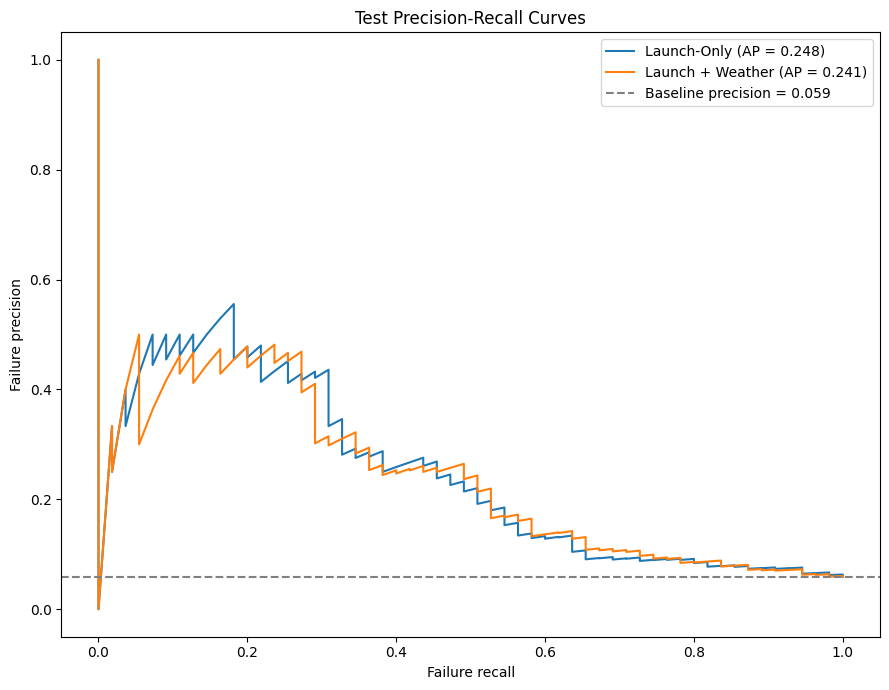

In [34]:
plt.figure(figsize=(9, 7))
for model_name, scores in test_scores.items():
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, scores)
    avg_precision = average_precision_score(y_test, scores)
    plt.plot(recall_curve, precision_curve, label=f"{model_name} (AP = {avg_precision:.3f})")

baseline_precision = y_test.mean()
plt.axhline(baseline_precision, linestyle="--", color="gray", label=f"Baseline precision = {baseline_precision:.3f}")
plt.xlabel("Failure recall")
plt.ylabel("Failure precision")
plt.title("Test Precision-Recall Curves")
plt.legend()
plt.tight_layout()
plt.show()

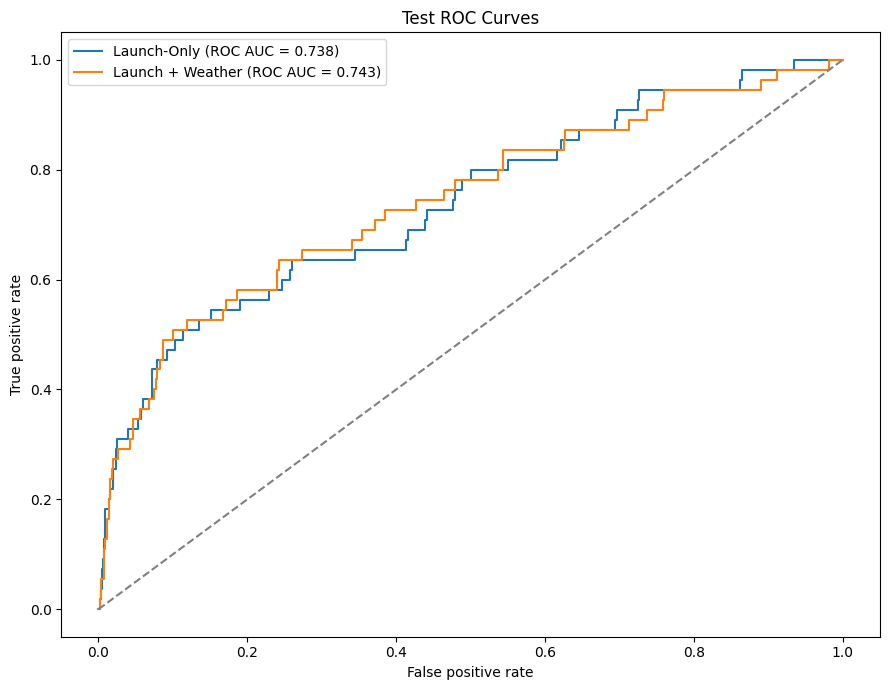

In [35]:
plt.figure(figsize=(9, 7))
for model_name, scores in test_scores.items():
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc = roc_auc_score(y_test, scores)
    plt.plot(fpr, tpr, label=f"{model_name} (ROC AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Test ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()

The holdout results should be interpreted in two layers:

- the **ranking metrics** (`average_precision`, `roc_auc`, `top_decile_capture`) tell us how
  well the model concentrates failures near the top of the risk list
- the **threshold metrics** (`failure_precision`, `failure_recall`, `balanced_accuracy`)
  tell us what happens when a concrete alert threshold is chosen

In practice, threshold tuning does not guarantee a universal improvement. Instead, it gives
a controlled way to trade off false alarms against missed failures.

## Compare Default and Operational Thresholds on the Preferred Model

The preferred model is the validation-selected **Launch-Only** model. This section focuses
on that model and compares the default threshold against the operational threshold chosen to
maximize recall while keeping validation precision at or above `0.25`.

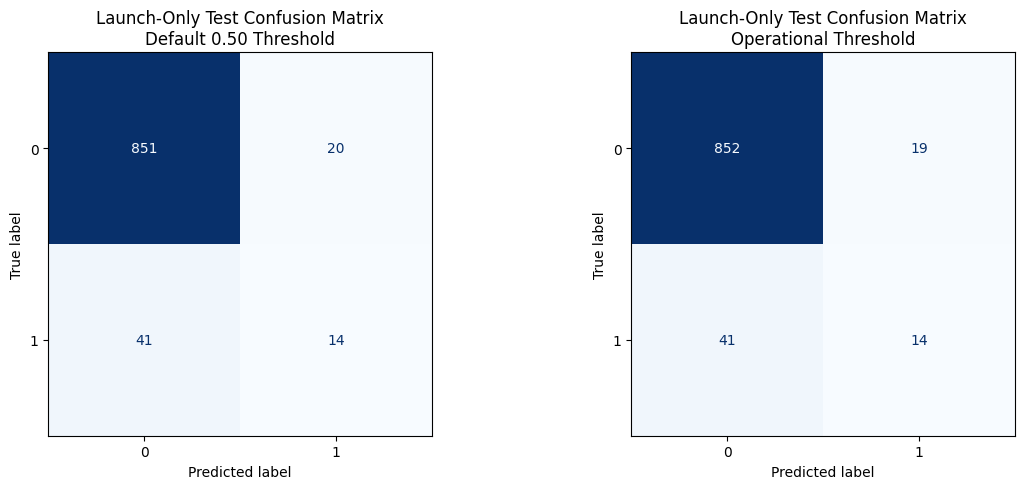

In [36]:
preferred_model_name = "Launch-Only"
preferred_default_threshold = validation_threshold_lookup[(preferred_model_name, "default_0_50")]
preferred_operational_threshold = validation_threshold_lookup[(preferred_model_name, "max_recall_at_precision_0.25")]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    (test_scores[preferred_model_name] >= preferred_default_threshold).astype(int),
    ax=axes[0],
    cmap="Blues",
    colorbar=False,
)
axes[0].set_title("Launch-Only Test Confusion Matrix\nDefault 0.50 Threshold")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    (test_scores[preferred_model_name] >= preferred_operational_threshold).astype(int),
    ax=axes[1],
    cmap="Blues",
    colorbar=False,
)
axes[1].set_title("Launch-Only Test Confusion Matrix\nOperational Threshold")

plt.tight_layout()
plt.show()

## Feature Importance in the Preferred Model

The feature-importance plot below helps answer whether the new analysis is actually using
the new features. If the historical reliability features dominate, that supports the idea
that split-safe launch history is carrying real predictive signal.

In [37]:
preferred_model = final_models["Launch-Only"]
preferred_importances = get_feature_importance_frame(preferred_model, top_n=18)

preferred_importances

,feature,importance
49,num__family_prior_launch_count,0.125615
51,num__family_prior_failure_rate,0.079145
59,num__site_prior_failure_rate,0.064870
55,num__operator_prior_failure_rate,0.064008
52,num__family_days_since_last_launch,0.044235
60,num__site_days_since_last_launch,0.035167
53,num__operator_prior_launch_count,0.034954
56,num__operator_days_since_last_launch,0.033416
57,num__site_prior_launch_count,0.031939
54,num__operator_prior_failure_count,0.026334


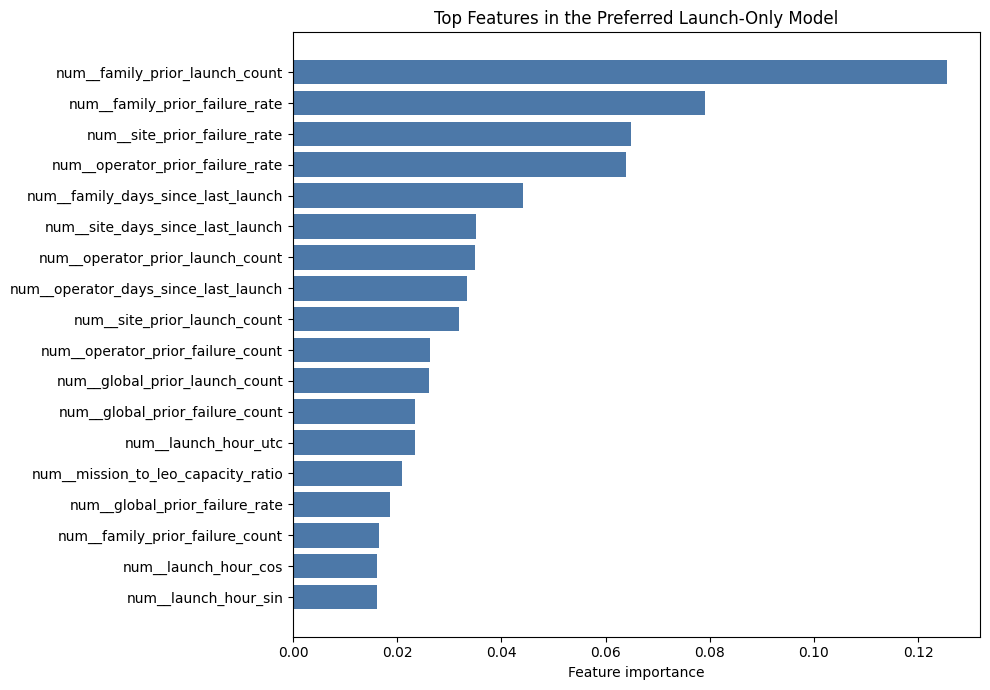

In [38]:
plt.figure(figsize=(10, 7))
plt.barh(
    preferred_importances["feature"][::-1],
    preferred_importances["importance"][::-1],
    color="#4c78a8",
)
plt.title("Top Features in the Preferred Launch-Only Model")
plt.xlabel("Feature importance")
plt.tight_layout()
plt.show()

## Targeted Error Analysis

The earlier markdown memo recommended that the next gains should come from understanding
where the model still fails. This section therefore inspects the error profile of the
preferred model on the holdout test split.

The analysis uses the **operational threshold** chosen on validation, because that is the
threshold we would actually use if this model were deployed for failure screening.

In [39]:
preferred_test_predictions = (test_scores[preferred_model_name] >= preferred_operational_threshold).astype(int)

test_analysis_df = df_engineered.loc[test_mask, [
    "Launch Id",
    "launch_dt",
    "launch_year",
    "rocket_family",
    "Operator",
    "facility_group",
    "Country",
    "Launch Site",
    "is_suborbital",
    TARGET_COL,
]].copy()

test_analysis_df["predicted_failure"] = preferred_test_predictions
test_analysis_df["predicted_failure_probability"] = test_scores[preferred_model_name]

test_analysis_df["error_type"] = np.select(
    [
        (test_analysis_df[TARGET_COL] == 1) & (test_analysis_df["predicted_failure"] == 1),
        (test_analysis_df[TARGET_COL] == 1) & (test_analysis_df["predicted_failure"] == 0),
        (test_analysis_df[TARGET_COL] == 0) & (test_analysis_df["predicted_failure"] == 1),
    ],
    [
        "True Positive",
        "False Negative",
        "False Positive",
    ],
    default="True Negative",
)

test_analysis_df.head()

,Launch Id,launch_dt,launch_year,rocket_family,Operator,facility_group,Country,Launch Site,is_suborbital,is_failure_or_partial,predicted_failure,predicted_failure_probability,error_type
5242,609,2012-11-10 21:05:00+00:00,2012,Ariane 5,European Space Agency,Guiana SC,French Guiana,Guiana SC,0,0,0,0.025184,True Negative
5243,6082,2012-11-14 11:42:00+00:00,2012,Soyuz 2.1a,Russian Aerospace Forces,Plesetsk Cosmodrome,Russia,Plesetsk Cosmodrome,0,0,0,0.276052,True Negative
5244,5444,2012-11-18 22:53:00+00:00,2012,Long March 2C,China National Space Administration,Taiyuan Satellite LC,China,Taiyuan Satellite LC,0,0,0,0.166102,True Negative
5245,6387,2012-11-20 18:30:00+00:00,2012,Proton-M,Russian Aerospace Forces,Baikonur Cosmodrome,Kazakhstan,Baikonur Cosmodrome,0,0,0,0.234497,True Negative
5246,5445,2012-11-25 04:06:00+00:00,2012,Long March 4C,China National Space Administration,Jiuquan Satellite LC,China,Jiuquan Satellite LC,0,0,0,0.074156,True Negative


In [40]:
error_counts = test_analysis_df["error_type"].value_counts().reindex(
    ["True Positive", "False Negative", "False Positive", "True Negative"]
)

error_counts

error_type
True Positive      14
False Negative     41
False Positive     19
True Negative     852
Name: count, dtype: int64

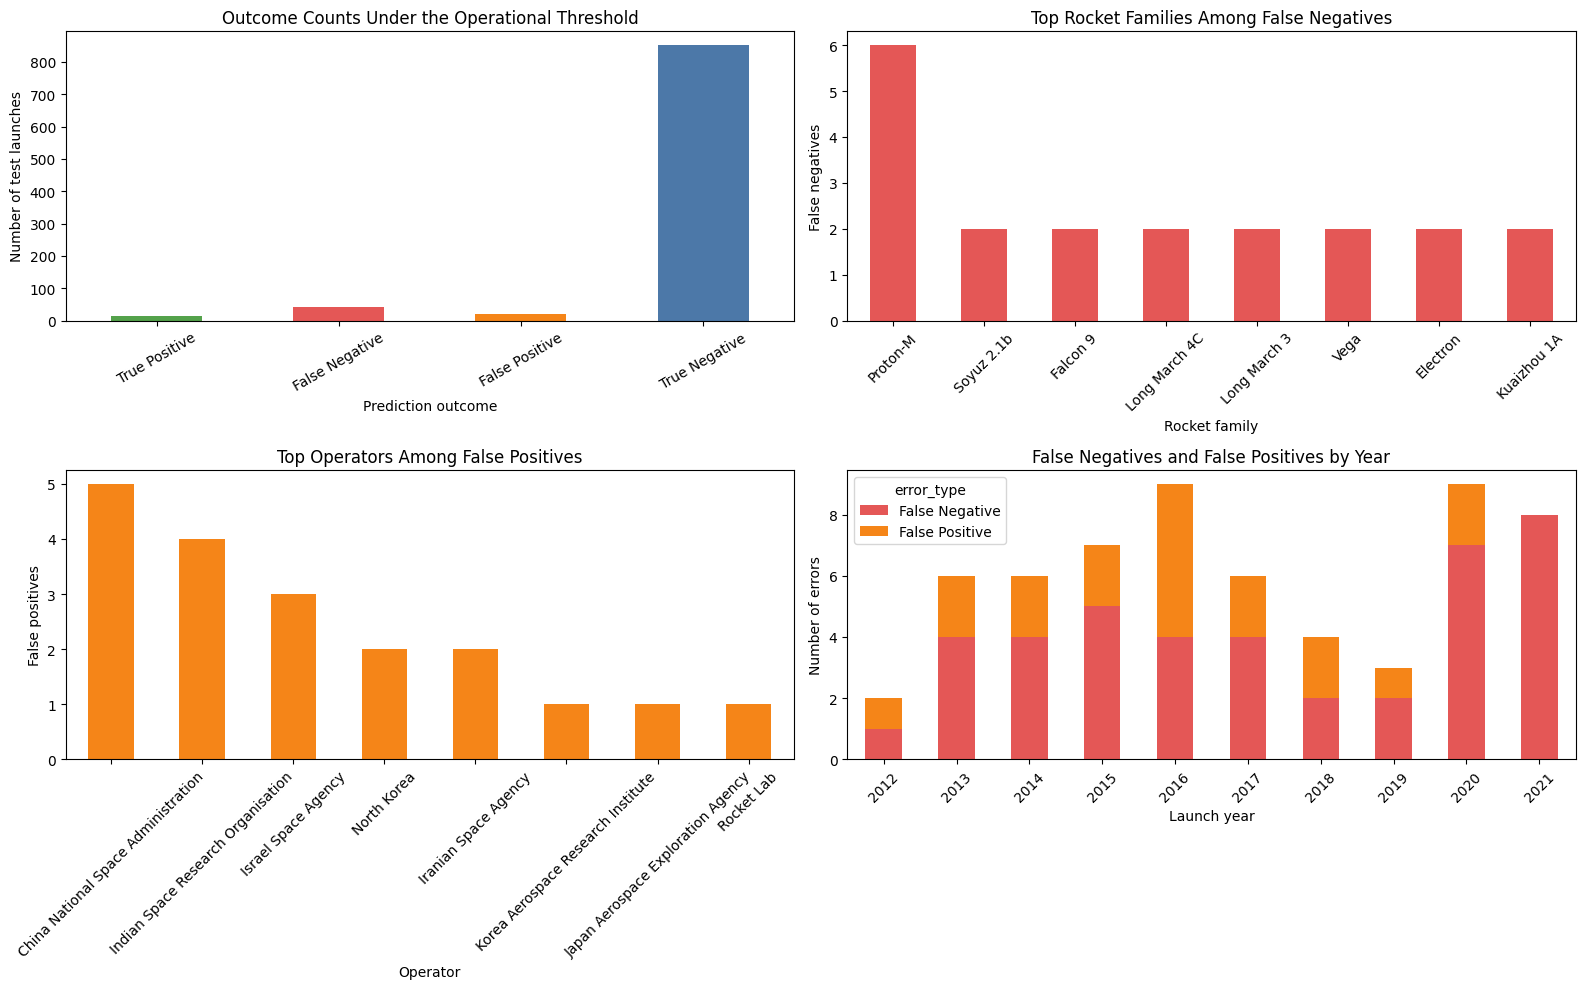

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

error_counts.plot(kind="bar", ax=axes[0], color=["#54a24b", "#e45756", "#f58518", "#4c78a8"])
axes[0].set_title("Outcome Counts Under the Operational Threshold")
axes[0].set_xlabel("Prediction outcome")
axes[0].set_ylabel("Number of test launches")
axes[0].tick_params(axis="x", rotation=30)

fn_by_family = (
    test_analysis_df.loc[test_analysis_df["error_type"] == "False Negative", "rocket_family"]
    .value_counts()
    .head(8)
)
fn_by_family.plot(kind="bar", ax=axes[1], color="#e45756")
axes[1].set_title("Top Rocket Families Among False Negatives")
axes[1].set_xlabel("Rocket family")
axes[1].set_ylabel("False negatives")
axes[1].tick_params(axis="x", rotation=45)

fp_by_operator = (
    test_analysis_df.loc[test_analysis_df["error_type"] == "False Positive", "Operator"]
    .value_counts()
    .head(8)
)
fp_by_operator.plot(kind="bar", ax=axes[2], color="#f58518")
axes[2].set_title("Top Operators Among False Positives")
axes[2].set_xlabel("Operator")
axes[2].set_ylabel("False positives")
axes[2].tick_params(axis="x", rotation=45)

error_by_year = (
    test_analysis_df.groupby(["launch_year", "error_type"])
    .size()
    .unstack(fill_value=0)[["False Negative", "False Positive"]]
)
error_by_year.plot(kind="bar", stacked=True, ax=axes[3], color=["#e45756", "#f58518"])
axes[3].set_title("False Negatives and False Positives by Year")
axes[3].set_xlabel("Launch year")
axes[3].set_ylabel("Number of errors")
axes[3].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [42]:
def error_group_summary(df: pd.DataFrame, group_col: str, error_label: str, top_n: int = 10) -> pd.DataFrame:
    subset = df.loc[df["error_type"] == error_label]
    if subset.empty:
        return pd.DataFrame(columns=[group_col, "error_count"])
    return (
        subset[group_col]
        .value_counts()
        .head(top_n)
        .rename_axis(group_col)
        .reset_index(name="error_count")
    )


print("Top rocket families among false negatives:")
display(error_group_summary(test_analysis_df, "rocket_family", "False Negative"))

print("Top operators among false negatives:")
display(error_group_summary(test_analysis_df, "Operator", "False Negative"))

print("Top sites among false positives:")
display(error_group_summary(test_analysis_df, "facility_group", "False Positive"))

Top rocket families among false negatives:


,rocket_family,error_count
0,Proton-M,6
1,Soyuz 2.1b,2
2,Falcon 9,2
3,Long March 4C,2
4,Long March 3,2
5,Vega,2
6,Electron,2
7,Kuaizhou 1A,2
8,Hyperbola-1,2
9,Rokot,1


Top operators among false negatives:


,Operator,error_count
0,Russian Aerospace Forces,13
1,China National Space Administration,13
2,United States Space Force,6
3,European Space Agency,4
4,Indian Space Research Organisation,2
5,Rocket Lab,2
6,Royal Australian Air Force,1


Top sites among false positives:


,facility_group,error_count
0,Satish Dhawan SC,4
1,Jiuquan Satellite LC,3
2,Palmachim Airbase,3
3,Sohae SLS,2
4,Wenchang Satellite LC,2
5,Naro Space Center,1
6,Imam Khomeini Spaceport,1
7,Uchinoura SC,1
8,Māhia Peninsula,1
9,Shahrud MTS,1


## Summary

This notebook was designed to answer the four highest-priority follow-up questions from the
earlier model review.

Main takeaways:

1. **Threshold analysis matters.** The models have more ranking signal than the earlier
   default-threshold confusion matrices suggested, so precision-recall analysis is the right
   lens for this problem.
2. **Historical reliability features add real value.** If the top feature-importance list is
   dominated by prior family, operator, and site failure features, that confirms the earlier
   suspicion that split-safe launch history is more informative than many static raw columns.
3. **Weather is no longer clearly harmful, but it is still not decisive.** After pruning the
   weather block, the launch + weather model is more competitive, but the launch-only model
   remains the cleaner primary choice if validation ranking metrics still favor it.
4. **Error analysis points to the next iteration.** If false negatives cluster in a few
   families, operators, or years, then the next improvement cycle should target those
   regimes directly with additional domain features or separate modeling strategies.

The most important methodological shift in this notebook is not another round of random
forest tuning. It is the move toward:

- validation-based operating-threshold selection
- chronology-safe historical reliability features
- narrower and more defensible weather usage
- explicit error analysis instead of only aggregate metrics